## 📋 Table of Contents

**Quick Start**: Just run all cells in order. Results will be saved to `results/max/` or `results/restricted/`.

### Analysis Pipeline

1. **Data Setup** (Cells 1-4)
   - Load dataset (auto-downloads if missing)
   - View data sources and availability
   
2. **Descriptive Statistics** (Cells 5-10)
   - Summary statistics tables
   - Exchange rate and PPP visualizations
   
3. **Model Estimation** (Cell 11-12)
   - STR model: Tests 35 transition variables, selects best
   - BUIP model: Behavioral regime-switching model
   - ⏱️ **Estimated time: 15-30 minutes for 14 countries**

4. **Results Tables** (Cells 13-25)
   - Transition variable selection
   - Parameter estimates with significance
   - Model diagnostics and validation
   
5. **Results Figures** (Cells 26-35)
   - Aggregate regime analysis
   - Country-specific transition dynamics
   - Regime probability plots

### 🔧 Configuration Options

- **Dataset mode**: Set `USE_MAX_DATASET = True/False` in Cell 3
- **Model selection**: Change `model_type='both'` in Cell 12 to `'str'` or `'buip'` only

### 📁 Output Files

All results saved to:
- Tables: `results/{mode}/tables/` (CSV + LaTeX)
- Figures: `results/{mode}/figures/` (PDF + PNG)

In [1]:
"""
STR-BUIP Exchange Rate Model Estimation
========================================

This notebook reproduces the main results for:
- STR (Smooth Transition Regression) models
- BUIP (Behavioral UIP) models

All estimation functions are located in src/analysis.py for code organization.
"""

# Setup notebook environment with standard imports and configuration
from src.notebook_setup import (
    np, pd, plt, Path,
    config, COUNTRIES, DATA_SOURCES,
    load_dataset, setup_notebook, print_dataset_summary,
    build_z_candidates, estimate_all_countries 
)
# Initialize environment
setup_notebook(title="STR-BUIP ESTIMATION PIPELINE")

STR-BUIP ESTIMATION PIPELINE

✓ Environment configured
✓ 14 countries available
✓ Output directory: /Users/lollo/Documents/Current_Projects/str-buip-estimation/results

Ready to run analysis!


### ⚠️ Reproducibility Notice

**The results should now be fully reproducible** across multiple runs. Recent fixes include:

1. **Random seed control**: BUIP multistart optimization uses `np.random.seed(42)` for consistent random initialization
2. **Deterministic iteration**: All dictionary and grid iterations are sorted for consistent ordering
3. **Sorted country processing**: Countries are processed alphabetically for reproducible output

**To verify reproducibility:**
1. Run the full notebook
2. Note down key results (e.g., gamma values, AIC/BIC)
3. Restart kernel and run again
4. Results should match exactly (within numerical precision ~1e-6)

**If you still observe differences**, check:
- Python version (tested on Python 3.8+)
- Package versions (see `Requirements.txt`)
- Operating system (minor numerical differences possible across platforms)

## 1. Load and Validate Data

This section loads (or builds) the panel dataset and displays data availability for each country.

In [2]:
"""
Load Panel Data
---------------
The dataset contains monthly exchange rate and macroeconomic data for 14 countries.
If the data file doesn't exist, it will be automatically built from DBnomics sources.

You can choose between:
- Restricted sample (default): 2000-01 to 2024-12
- Maximum-length sample: longest span with all three key series (S, CPI, policy rate),
  with custom trims for Indonesia, Korea, and Philippines.
Set USE_MAX_DATASET = True to use the maximum-length dataset.
"""

# Choose dataset
USE_MAX_DATASET = True  # <- set to True to use maximum-length dataset

# Load dataset and configure output directories
df_panel, output_dir, tables_dir, agg_fig_dir, country_fig_dir = load_dataset(use_max=USE_MAX_DATASET)

# Print summary
print_dataset_summary(df_panel)


DATASET SUMMARY
Total observations: 6,721
Countries: 14
Date range: 1982-09-30 00:00:00 to 2025-07-31 00:00:00

Observations per country:
country
Australia         512
Brazil            514
Canada            514
Euro Area         318
Indonesia         468
Japan             479
Korea             513
Mexico            514
New Zealand       483
Philippines       472
Switzerland       515
Thailand          434
Türkiye           470
United Kingdom    515
Name: count, dtype: int64


In [3]:
# Display data availability and sources
print("\nData Availability and Sources:")

summary_data = []
for country in df_panel['country'].unique():
    country_df = df_panel[df_panel['country'] == country]
    summary_data.append({
        'Country': country,
        'Start Date': country_df['date'].min().strftime('%Y-%m'),
        'End Date': country_df['date'].max().strftime('%Y-%m'),
        'Observations': len(country_df),
        'Source': DATA_SOURCES.get(country, 'IMF/IFS')
    })

df_summary = pd.DataFrame(summary_data)
display(df_summary)

# Save data availability table
csv_path = tables_dir / 'data_availability_sources.csv'
tex_path = tables_dir / 'data_availability_sources.tex'

df_summary.to_csv(csv_path, index=False)
with open(tex_path, 'w') as f:
    f.write(df_summary.to_latex(
        index=False,
        escape=False,
        caption='Data Availability and Sources by Country. S=Exchange Rate, CPI=Consumer Price Index, i=Policy/Interest Rate, MM=Money Market Rate. All data accessed via DBnomics API.',
        label='tab:data_availability'
    ))

print(f"\n✓ Saved: {csv_path.name}")
print(f"✓ Saved: {tex_path.name}")


Data Availability and Sources:


,Country,Start Date,End Date,Observations,Source
0,Australia,1982-09,2025-04,512,"IMF/IFS (S, CPI interp., i)"
1,Brazil,1982-09,2025-06,514,"IMF/IFS (S, CPI, MM rate)"
2,Canada,1982-09,2025-06,514,"IMF/IFS (S, CPI), OECD (i)"
3,Euro Area,1999-02,2025-07,318,"IMF/IFS (S, CPI), OECD (i)"
4,Indonesia,1986-06,2025-05,468,"IMF/IFS (S, CPI, i combined)"
5,Japan,1985-08,2025-06,479,"IMF/IFS (S, CPI), OECD (i)"
6,Korea,1982-09,2025-05,513,"IMF/IFS (S, CPI, MM rate)"
7,Mexico,1982-09,2025-06,514,"IMF/IFS (S, CPI, MM rate)"
8,New Zealand,1985-02,2025-04,483,"IMF/IFS (S, CPI interp., MM rate)"
9,Philippines,1982-09,2021-12,472,"IMF/IFS (S, CPI, MM rate)"



✓ Saved: data_availability_sources.csv
✓ Saved: data_availability_sources.tex


---

## 2. Descriptive Statistics

Generate summary statistics and visualizations for exchange rate returns and fundamental values across all countries.

In [4]:
"""
Compute descriptive statistics for:
- Exchange rate returns (r_s)
- Fundamental value (log CPI differential: log(p_dom) - log(p_for))
"""
from scipy import stats as sp_stats

stats_rows = []
for country_name in COUNTRIES.keys():
    sub = df_panel[df_panel['country'] == country_name].copy()
    if len(sub) == 0:
        continue
    
    # Exchange rate returns
    r_s = pd.to_numeric(sub['r_s'], errors='coerce').dropna()
    
    # Fundamental value (log CPI differential)
    fv = (np.log(sub['p_dom']) - np.log(sub['p_for'])).dropna()
    
    stats_rows.append({
        'Country': country_name,
        'Mean_r_s': r_s.mean(),
        'Var_r_s': r_s.var(ddof=1),
        'Skew_r_s': sp_stats.skew(r_s),
        'Kurt_r_s': sp_stats.kurtosis(r_s),
        'Mean_f': fv.mean(),
        'Var_f': fv.var(ddof=1)
    })

df_desc = pd.DataFrame(stats_rows).set_index('Country')
print("\n=== DESCRIPTIVE STATISTICS ===")
print(df_desc.round(4))

# Save outputs
csv_path = tables_dir / 'descriptive_statistics.csv'
tex_path = tables_dir / 'descriptive_statistics.tex'
df_desc.round(4).to_csv(csv_path)

# Create LaTeX version with math formatting
df_desc_latex = df_desc.copy()
df_desc_latex.columns = [
    r'$Mean_{\Delta s}$',
    r'$Var_{\Delta s}$',
    r'$Skew_{\Delta s}$',
    r'$Kurt_{\Delta s}$',
    r'$Mean_{f}$',
    r'$Var_{f}$'
]
with open(tex_path, 'w') as f:
    f.write(df_desc_latex.round(4).to_latex(
        float_format=lambda x: f"{x:.4f}", 
        escape=False, 
        caption='Descriptive Statistics: Exchange Rate Returns & Fundamental Value', 
        label='tab:desc_stats'
    ))

print(f"\n✓ Saved: {csv_path.name}")
print(f"✓ Saved: {tex_path.name}")


=== DESCRIPTIVE STATISTICS ===
                Mean_r_s  Var_r_s  Skew_r_s  Kurt_r_s  Mean_f   Var_f
Country                                                              
Australia         0.0008   0.0010    0.7045    2.5387 -0.0086  0.0002
Brazil            0.0488   0.0104    1.6606    3.1150 -0.0399  0.0536
Canada            0.0002   0.0004    0.4249    3.9327  0.0092  0.0002
Euro Area        -0.0000   0.0007    0.1595    1.2867 -0.0021  0.0001
Indonesia         0.0057   0.0037    5.3678   69.4273 -0.1421  0.0415
Japan            -0.0010   0.0009   -0.2226    1.3990  0.0342  0.0031
Korea             0.0012   0.0009    0.7188   12.5920 -0.0292  0.0012
Mexico            0.0116   0.0024    6.0905   68.4200 -0.1979  0.2350
New Zealand      -0.0005   0.0012    0.3714    1.2110 -0.0008  0.0001
Philippines       0.0038   0.0008    3.5908   25.9394 -0.0919  0.0162
Switzerland      -0.0019   0.0010   -0.1025    0.9630  0.0162  0.0019
Thailand          0.0007   0.0008    0.2737   27.8384 -0.0

### 2.1 Raw Series Overview (All Countries)

Three figures (7x2 subplots) showing per-country time series for:
- Exchange rate level `S`
- Domestic CPI `CPI_dom`
- Domestic policy rate `i_dom` (monthly effective)

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Helper to create 7x2 subplot grid
COUNTRY_LIST = list(COUNTRIES.keys())
rows, cols = 7, 2

# 1) Exchange Rate S
fig, axes = plt.subplots(rows, cols, figsize=(14, 16), sharex=False)
axes = axes.flatten()
for i, country in enumerate(COUNTRY_LIST):
    sub = df_panel[df_panel['country'] == country].sort_values('date')
    axes[i].plot(sub['date'], sub['S'], color='black', linewidth=0.8)
    axes[i].set_title(country, fontsize=9)
    axes[i].grid(False)
for ax in axes[(rows-1)*cols:]:
    ax.set_xlabel('Date')
fig.suptitle('Exchange Rate Level (S)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
path_png = agg_fig_dir / 'raw_series_exchange_rate.png'
path_pdf = agg_fig_dir / 'raw_series_exchange_rate.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
plt.close(fig)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

# 2) Domestic CPI
fig, axes = plt.subplots(rows, cols, figsize=(14, 16), sharex=False)
axes = axes.flatten()
for i, country in enumerate(COUNTRY_LIST):
    sub = df_panel[df_panel['country'] == country].sort_values('date')
    axes[i].plot(sub['date'], sub['CPI_dom'], color='black', linewidth=0.8)
    axes[i].set_title(country, fontsize=9)
    axes[i].grid(False)
for ax in axes[(rows-1)*cols:]:
    ax.set_xlabel('Date')
fig.suptitle('Domestic CPI (CPI_dom)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
path_png = agg_fig_dir / 'raw_series_cpi_dom.png'
path_pdf = agg_fig_dir / 'raw_series_cpi_dom.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
plt.close(fig)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

# 3) Domestic Policy Rate (monthly effective)
fig, axes = plt.subplots(rows, cols, figsize=(14, 16), sharex=False)
axes = axes.flatten()
for i, country in enumerate(COUNTRY_LIST):
    sub = df_panel[df_panel['country'] == country].sort_values('date')
    axes[i].plot(sub['date'], sub['i_dom'], color='black', linewidth=0.8)
    axes[i].set_title(country, fontsize=9)
    axes[i].grid(False)
for ax in axes[(rows-1)*cols:]:
    ax.set_xlabel('Date')
fig.suptitle('Domestic Policy Rate i_dom (monthly effective)', fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
path_png = agg_fig_dir / 'raw_series_interest_dom.png'
path_pdf = agg_fig_dir / 'raw_series_interest_dom.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
plt.close(fig)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

✓ Saved: raw_series_exchange_rate.png, raw_series_exchange_rate.pdf
✓ Saved: raw_series_cpi_dom.png, raw_series_cpi_dom.pdf
✓ Saved: raw_series_interest_dom.png, raw_series_interest_dom.pdf


In [6]:
# Log Nominal Exchange Rate vs Log PPP (6-panel: Advanced vs Emerging)
import matplotlib.dates as mdates

advanced_countries = ["United Kingdom", "Japan", "Switzerland"]
emerging_countries = ["Brazil", "Mexico", "Türkiye"]
plot_countries = advanced_countries + emerging_countries

# Slightly shorter figure height for compact subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=False)
axes = axes.flatten()

for idx, country in enumerate(plot_countries):
    ax = axes[idx]
    sub = df_panel[df_panel['country'] == country].sort_values('date').copy()
    # Require non-missing observations for comparability
    sub = sub[['date', 'S', 'CPI_dom', 'CPI_for']].dropna()
    if sub.empty:
        ax.set_visible(False)
        continue
    log_s = np.log(sub['S'])
    log_ppp = np.log(sub['CPI_dom']) - np.log(sub['CPI_for'])
    # Normalize to first observation
    log_s = log_s - log_s.iloc[0]
    log_ppp = log_ppp - log_ppp.iloc[0]
    ax.plot(sub['date'], log_s, color='black', linewidth=1.0, label='log S (normalized)')
    ax.plot(sub['date'], log_ppp, color='dimgray', linewidth=1.0, linestyle='--', label='log PPP (normalized)')
    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(False)

# Shared labels and legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=12)
fig.suptitle('Log Nominal Exchange Rate vs Log PPP (Advanced vs Emerging)', fontsize=15)
plt.tight_layout(rect=[0, 0.05, 1, 0.93])

# Save outputs
fig_path_pdf = agg_fig_dir / 'log_nominal_vs_ppp_6panel.pdf'
fig_path_png = agg_fig_dir / 'log_nominal_vs_ppp_6panel.png'
fig.savefig(fig_path_pdf, bbox_inches='tight')
fig.savefig(fig_path_png, dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"\n✓ Saved: {fig_path_pdf.name}")
print(f"✓ Saved: {fig_path_png.name}")


✓ Saved: log_nominal_vs_ppp_6panel.pdf
✓ Saved: log_nominal_vs_ppp_6panel.png


In [7]:
# Returns of Log Nominal Exchange Rate vs Returns of Log PPP (6-panel)
import matplotlib.dates as mdates

advanced_countries_ret = ["United Kingdom", "Japan", "Switzerland"]
emerging_countries_ret = ["Brazil", "Mexico", "Türkiye"]
plot_countries_ret = advanced_countries_ret + emerging_countries_ret

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=False)
axes = axes.flatten()

for idx, country in enumerate(plot_countries_ret):
    ax = axes[idx]
    sub = df_panel[df_panel['country'] == country].sort_values('date').copy()
    sub = sub[['date', 'S', 'CPI_dom', 'CPI_for']].dropna()
    if len(sub) < 2:
        ax.set_visible(False)
        continue
    log_s = np.log(sub['S'])
    log_ppp = np.log(sub['CPI_dom']) - np.log(sub['CPI_for'])
    # Compute returns (first difference) and align dates
    ret_s = log_s.diff().dropna()
    ret_ppp = log_ppp.diff().dropna()
    # Align series on common dates after diff
    aligned = pd.concat([ret_s, ret_ppp], axis=1, join='inner')
    aligned.columns = ['ret_s', 'ret_ppp']
    if aligned.empty:
        ax.set_visible(False)
        continue
    ax.plot(aligned.index, aligned['ret_s'], color='black', linewidth=0.9, label='Δ log S ')
    ax.plot(aligned.index, aligned['ret_ppp'], color='red', linewidth=0.9, linestyle='--', label='Δ log PPP')
    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(False)

# Legend below the grid
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
fig.suptitle('Returns: Δlog S vs Δlog PPP (Advanced vs Emerging)', fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 0.93])

# Save outputs
fig_path_pdf = agg_fig_dir / 'returns_logS_vs_logPPP_6panel.pdf'
fig_path_png = agg_fig_dir / 'returns_logS_vs_logPPP_6panel.png'
fig.savefig(fig_path_pdf, bbox_inches='tight')
fig.savefig(fig_path_png, dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"\n✓ Saved: {fig_path_pdf.name}")
print(f"✓ Saved: {fig_path_png.name}")


✓ Saved: returns_logS_vs_logPPP_6panel.pdf
✓ Saved: returns_logS_vs_logPPP_6panel.png


## 3. Model Estimation

⏱️ **This is the longest step - allow 15-30 minutes**

This section estimates two types of nonlinear models:

**STR Model** (Smooth Transition Regression):
- Tests 35 candidate transition variables per country
- Selects the variable with strongest nonlinearity (lowest LM test p-value)
- Estimates regime-switching parameters via grid search + nonlinear least squares

**BUIP Model** (Behavioral UIP):
- Models agent behavior switching between chartist and fundamentalist strategies
- Uses utility-based threshold to determine regime transitions
- Employs multistart optimization to avoid local minima

All estimation functions are implemented in `src/analysis.py` for maintainability.

In [8]:
"""
Estimate STR and BUIP models for all countries.

⏱️ Estimated time: 15-30 minutes for 14 countries (1-2 min per country)

This will:
1. For STR: Test 35 transition variable candidates, select best via LM test, estimate via grid search + NLS
2. For BUIP: Estimate behavioral model with multistart optimization

Progress and results will be printed for each country.
"""

import time
start_time = time.time()

# Run estimation pipeline (defined in src/analysis.py)
print("Starting model estimation...")
print(f"Total countries: {len(COUNTRIES)}")
print("=" * 60)

str_results, buip_results = estimate_all_countries(df_panel, COUNTRIES, model_type='both')

elapsed = time.time() - start_time
print(f"\n{'='*60}")
print(f"ESTIMATION SUMMARY")
print(f"{'='*60}")
print(f"STR models successfully estimated: {len(str_results)} / {len(COUNTRIES)}")
print(f"BUIP models successfully estimated: {len(buip_results)} / {len(COUNTRIES)}")
print(f"Total time: {elapsed/60:.1f} minutes ({elapsed/len(COUNTRIES):.1f} sec per country)")
print(f"{'='*60}")

Starting model estimation...
Total countries: 14

Processing Australia
Running linearity tests for 35 candidates...
Best transition variable: rel_misalignment_abs_lag3 (p=0.0000)
Running grid search...
Grid search complete. Starting NLS...

STR Results for Australia:
const      15.112907
beta_c    294.294383
beta_f     -0.017944
gamma       0.407091
c          -0.419054
const1    -15.107314
dtype: float64
AIC: -3485.40, BIC: -3460.01

BUIP: Australia
Sample size: 509
Running scientifically-grounded multistart optimization...
  Strategy: Two-stage conditional OLS + refinement

BUIP Results for Australia:
beta_f     -0.015871
beta_c      0.012348
gamma     812.787795
c          -0.137748
const       0.045538
const1     -0.038167
dtype: float64
AIC: -3494.91, BIC: -3469.51

Processing Brazil
Running linearity tests for 35 candidates...
Best transition variable: rel_misalignment_abs_lag2 (p=0.0000)
Running grid search...
Grid search complete. Starting NLS...

STR Results for Brazil:
const 

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '


Grid search complete. Starting NLS...

STR Results for Indonesia:
const       0.009134
beta_c      0.406343
beta_f     -0.073298
gamma     198.124486
c           0.072152
const1      0.704285
dtype: float64
AIC: -2644.93, BIC: -2620.09

BUIP: Indonesia
Sample size: 465
Running scientifically-grounded multistart optimization...
  Strategy: Two-stage conditional OLS + refinement

BUIP Results for Indonesia:
beta_f   -0.042872
beta_c   -4.303610
gamma     2.224051
c        -0.513657
const     1.848171
const1   -1.445005
dtype: float64
AIC: -2888.09, BIC: -2863.24

Processing Japan
Running linearity tests for 35 candidates...
Best transition variable: rel_misalignment_abs_lag2 (p=0.0000)
Running grid search...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have ful

Grid search complete. Starting NLS...

STR Results for Japan:
const      -0.002005
beta_c      0.227408
beta_f      0.008557
gamma     512.000106
c           0.027922
const1     -0.040815
dtype: float64
AIC: -3347.17, BIC: -3322.17

BUIP: Japan
Sample size: 476
Running scientifically-grounded multistart optimization...
  Strategy: Two-stage conditional OLS + refinement

BUIP Results for Japan:
beta_f    -0.002708
beta_c    56.778009
gamma      0.016391
c        -14.268697
const      1.075978
const1    -1.068637
dtype: float64
AIC: -3335.19, BIC: -3310.20

Processing Korea
Running linearity tests for 35 candidates...
Best transition variable: rel_misalignment_abs_lag4 (p=0.0000)
Running grid search...


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have ful

Grid search complete. Starting NLS...

STR Results for Korea:
const     0.003490
beta_c    0.268376
beta_f   -0.421459
gamma     1.287148
c         0.082158
const1    3.000272
dtype: float64
AIC: -3646.03, BIC: -3620.63

BUIP: Korea
Sample size: 510
Running scientifically-grounded multistart optimization...
  Strategy: Two-stage conditional OLS + refinement

BUIP Results for Korea:
beta_f   -0.035248
beta_c    1.977587
gamma     7.962941
c        -0.551258
const     0.521759
const1   -0.271104
dtype: float64
AIC: -3657.41, BIC: -3632.01

Processing Mexico
Running linearity tests for 35 candidates...
Best transition variable: rel_misalignment_abs_lag4 (p=0.0000)
Running grid search...
Grid search complete. Starting NLS...

STR Results for Mexico:
const      72.871358
beta_c    751.389216
beta_f      0.081358
gamma       0.906363
c          -0.332447
const1    -73.084573
dtype: float64
AIC: -3189.84, BIC: -3164.43

BUIP: Mexico
Sample size: 511
Running scientifically-grounded multistart 

---

## 4. Results Tables

Generate publication-ready tables with parameter estimates, significance stars, and model diagnostics.

### 4.1 Transition Variable Selection Table

Shows which transition variable was selected for each country based on the LM linearity test.

In [9]:
"""
Generate table showing the selected transition variable for each country.
The transition variable with the lowest p-value in the LM linearity test is selected.
"""

print("\n" + "="*60)
print("TRANSITION VARIABLE SELECTION TABLE")
print("="*60)

# Build table from STR results
tv_selection_rows = []
for country_name in COUNTRIES.keys():
    if country_name in str_results:
        result_dict = str_results[country_name]
        tv_selection_rows.append({
            'Country': country_name,
            'Transition Variable': result_dict['z_name'],
            'P-value': f"{result_dict['lm_pval']:.4f}"
        })
    else:
        tv_selection_rows.append({
            'Country': country_name,
            'Transition Variable': 'N/A',
            'P-value': 'N/A'
        })

df_tv_selection = pd.DataFrame(tv_selection_rows)
print("\n")
print(df_tv_selection.to_string(index=False))

# Save outputs
csv_path = tables_dir / 'transition_variable_selection.csv'
tex_path = tables_dir / 'transition_variable_selection.tex'

df_tv_selection.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path.name}")

# Create LaTeX version
with open(tex_path, 'w') as f:
    f.write(df_tv_selection.to_latex(
        index=False,
        escape=False,
        caption='Selected Transition Variables for STR Models (LM Linearity Test)',
        label='tab:transition_variables'
    ))
print(f"✓ Saved: {tex_path.name}")


TRANSITION VARIABLE SELECTION TABLE


       Country       Transition Variable P-value
     Australia rel_misalignment_abs_lag3  0.2426
        Brazil rel_misalignment_abs_lag2  0.0000
        Canada rel_misalignment_abs_lag2  0.0000
     Euro Area              drs_abs_lag3  0.0112
     Indonesia rel_misalignment_abs_lag4  0.0000
         Japan rel_misalignment_abs_lag2  0.0071
         Korea rel_misalignment_abs_lag4  0.0000
        Mexico rel_misalignment_abs_lag4  0.0000
   New Zealand               ID_abs_lag4  0.0059
   Philippines              drs_abs_lag3  0.0173
   Switzerland              drf_abs_lag2  0.0000
      Thailand              drf_abs_lag5  0.0000
       Türkiye              drf_abs_lag4  0.0000
United Kingdom              drf_abs_lag3  0.0151

✓ Saved: transition_variable_selection.csv
✓ Saved: transition_variable_selection.tex


### Transition Variable Symbols (for paper use)
Below is the mapping from result names to the math symbols used in the article (lag `k` ∈ {1,…,5}).

- eta_abs_lagk: $|\eta_{t-k}|$ — absolute real exchange rate.
- ID_abs_lagk: $|(i^{*}_{t-k} - i_{t-k})|$ — absolute interest rate differential (foreign minus domestic).
- ppp_abs_lagk: $|f_{t-k}|$ — absolute PPP deviation.
- drf_abs_lagk: $|\Delta f_{t-k}|$ — absolute PPP deviation change.
- rel_misalignment_abs_lagk: $|\Delta f_{t-k} - \Delta s_{t-k}|$ — absolute relative misalignment.
- drs_abs_lagk: $|\Delta s_{t-k}|$ — absolute nominal exchange rate log return.
- excess_returns_abs_lagk: $|\Delta s_{t-k} - (i^{*}_{t-k} - i_{t-k})|$ — absolute excess returns.


### 4.2 STR and BUIP Models Estimation Results

In [10]:
"""
Generate results tables for STR and BUIP models.
Estimates significant at 5% level are shown in bold.
"""

def format_with_stars(estimate, pval):
    """Format estimates with significance stars. Bold if p < 0.05."""
    if np.isnan(pval) or np.isnan(estimate):
        return ''
    val_str = f"{estimate:.4f}"
    if pval < 0.01:
        return f"\\textbf{{{val_str}}}***"
    if pval < 0.05:
        return f"\\textbf{{{val_str}}}**"
    if pval < 0.10:
        return f"{val_str}*"
    return val_str

# ============================================================================
# STR Results Table
# ============================================================================
print("\n" + "="*60)
print("GENERATING STR RESULTS TABLE")
print("="*60)

str_rows = []
for country_name in COUNTRIES.keys():
    if country_name in str_results:
        res = str_results[country_name]['result']
        row = {'Country': country_name}
        for param in ['const', 'const1', 'beta_c', 'beta_f', 'gamma', 'c']:
            est = res.params.get(param, np.nan)
            pval = res.pvals.get(param, np.nan)
            row[param] = format_with_stars(est, pval)
        str_rows.append(row)
    else:
        str_rows.append({
            'Country': country_name,
            'const': '', 'const1': '', 'beta_c': '', 'beta_f': '', 'gamma': '', 'c': ''
        })

df_str_table = pd.DataFrame(str_rows).set_index('Country')
print(df_str_table)

# Save outputs
str_csv = tables_dir / 'str_results_table.csv'
str_tex = tables_dir / 'str_results_table.tex'
df_str_table.to_csv(str_csv)
with open(str_tex, 'w') as f:
    f.write(df_str_table.to_latex(escape=False, caption='STR Model Estimates', label='tab:str_results'))

print(f"\n✓ Saved: {str_csv.name}")
print(f"✓ Saved: {str_tex.name}")

# ============================================================================
# BUIP Results Table
# ============================================================================
print("\n" + "="*60)
print("GENERATING BUIP RESULTS TABLE")
print("="*60)

buip_rows = []
for country_name in COUNTRIES.keys():
    if country_name in buip_results:
        res = buip_results[country_name]
        row = {'Country': country_name}
        for param in ['const', 'const1', 'beta_c', 'beta_f', 'gamma', 'c']:
            est = res.params.get(param, np.nan)
            pval = res.pvals.get(param, np.nan)
            row[param] = format_with_stars(est, pval)
        buip_rows.append(row)
    else:
        buip_rows.append({
            'Country': country_name,
            'const': '', 'const1': '', 'beta_c': '', 'beta_f': '', 'gamma': '', 'c': ''
        })

df_buip_table = pd.DataFrame(buip_rows).set_index('Country')
print(df_buip_table)

# Save outputs
buip_csv = tables_dir / 'buip_results_table.csv'
buip_tex = tables_dir / 'buip_results_table.tex'
df_buip_table.to_csv(buip_csv)
with open(buip_tex, 'w') as f:
    f.write(df_buip_table.to_latex(escape=False, caption='BUIP Model Estimates', label='tab:buip_results'))

print(f"\n✓ Saved: {buip_csv.name}")
print(f"✓ Saved: {buip_tex.name}")


GENERATING STR RESULTS TABLE
                              const              const1              beta_c  \
Country                                                                       
Australia                   15.1129            -15.1073            294.2944   
Brazil                       0.0139  \textbf{0.3476}***  \textbf{1.9925}***   
Canada                      -0.0002              0.0056   \textbf{0.1816}**   
Euro Area                   -0.0059              0.0029              0.0840   
Indonesia        \textbf{0.0091}***              0.7043              0.4063   
Japan                       -0.0020             -0.0408  \textbf{0.2274}***   
Korea             \textbf{0.0035}**  \textbf{3.0003}***              0.2684   
Mexico                      72.8714            -73.0846            751.3892   
New Zealand                  0.0005  \textbf{0.0351}***  \textbf{-0.1446}**   
Philippines      \textbf{0.0295}***              0.0023             -0.0288   
Switzerland     \textb

### 4.3 STR and BUIP Models Estimation Results with Confidence Intervals

In [11]:
"""
Generate enhanced results tables with confidence intervals for STR and BUIP models.
Confidence intervals (95%) are shown in parentheses below each estimate in smaller font.
Uses makecell package for proper LaTeX formatting.
"""

def format_with_ci(estimate, stderr, pval, alpha=0.05):
    """
    Format estimates with 95% confidence intervals below using makecell.
    Estimates significant at 5% level are shown in bold.
    """
    if np.isnan(pval) or np.isnan(estimate) or np.isnan(stderr):
        return ''
    
    # Calculate 95% CI
    from scipy.stats import norm
    z_crit = norm.ppf(1 - alpha/2)
    ci_lower = estimate - z_crit * stderr
    ci_upper = estimate + z_crit * stderr
    
    # Format estimate with stars
    val_str = f"{estimate:.4f}"
    if pval < 0.01:
        est_line = f"\\textbf{{{val_str}}}***"
    elif pval < 0.05:
        est_line = f"\\textbf{{{val_str}}}**"
    elif pval < 0.10:
        est_line = f"{val_str}*"
    else:
        est_line = val_str
    
    # Format CI in small font - use makecell for proper line break
    ci_line = f"\\scriptsize{{({ci_lower:.4f}, {ci_upper:.4f})}}"
    
    return f"\\makecell{{{est_line} \\\\ {ci_line}}}"

print("\n" + "="*60)
print("GENERATING ENHANCED TABLES WITH CONFIDENCE INTERVALS")
print("="*60)

# ============================================================================
# STR Results Table with Confidence Intervals
# ============================================================================
print("\nGenerating STR table with confidence intervals...")

str_rows_ci = []
for country_name in COUNTRIES.keys():
    if country_name in str_results:
        res = str_results[country_name]['result']
        row = {'Country': country_name}
        for param in ['const', 'const1', 'beta_c', 'beta_f', 'gamma', 'c']:
            est = res.params.get(param, np.nan)
            se = res.se.get(param, np.nan)
            pval = res.pvals.get(param, np.nan)
            row[param] = format_with_ci(est, se, pval)
        str_rows_ci.append(row)
    else:
        str_rows_ci.append({
            'Country': country_name,
            'const': '', 'const1': '', 'beta_c': '', 'beta_f': '', 'gamma': '', 'c': ''
        })

df_str_ci = pd.DataFrame(str_rows_ci).set_index('Country')

# Create LaTeX table with proper formatting
str_ci_tex = tables_dir / 'str_results_with_ci.tex'
with open(str_ci_tex, 'w') as f:
    f.write(r"""\begin{table}[htbp]
\centering
\caption{STR Model Estimation Results with 95\% Confidence Intervals}
\label{tab:str_results_ci}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cccccc}
\toprule
Country & $\alpha_0$ & $\alpha_1$ & $\beta_c$ & $\beta_f$ & $\gamma$ & $c$ \\
\midrule
""")
    
    for country, row in df_str_ci.iterrows():
        f.write(f"{country:20s}")
        for param in ['const', 'const1', 'beta_c', 'beta_f', 'gamma', 'c']:
            val = row[param] if row[param] else ' '
            f.write(f" & {val}")
        f.write(" \\\\\n")
    
    f.write(r"""\bottomrule
\end{tabular}%
}
\begin{tablenotes}[para,flushleft]
\small
\textit{Note}: 95\% confidence intervals shown in parentheses below parameter estimates. 
Significance levels: *** $p<0.01$, ** $p<0.05$, * $p<0.10$. 
Bold estimates are significant at 5\% level.
$\alpha_0$, $\alpha_1$ = intercepts; $\beta_c$ = chartist coefficient; 
$\beta_f$ = fundamentalist coefficient; $\gamma$ = transition speed; $c$ = threshold.
Requires \texttt{makecell} package.
\end{tablenotes}
\end{table}
""")

print(f"✓ Saved: {str_ci_tex.name}")

# ============================================================================
# BUIP Results Table with Confidence Intervals
# ============================================================================
print("Generating BUIP table with confidence intervals...")

buip_rows_ci = []
for country_name in COUNTRIES.keys():
    if country_name in buip_results:
        res = buip_results[country_name]
        row = {'Country': country_name}
        for param in ['const', 'const1', 'beta_c', 'beta_f', 'gamma', 'c']:
            est = res.params.get(param, np.nan)
            se = res.se.get(param, np.nan)
            pval = res.pvals.get(param, np.nan)
            row[param] = format_with_ci(est, se, pval)
        buip_rows_ci.append(row)
    else:
        buip_rows_ci.append({
            'Country': country_name,
            'const': '', 'const1': '', 'beta_c': '', 'beta_f': '', 'gamma': '', 'c': ''
        })

df_buip_ci = pd.DataFrame(buip_rows_ci).set_index('Country')

# Create LaTeX table with proper formatting
buip_ci_tex = tables_dir / 'buip_results_with_ci.tex'
with open(buip_ci_tex, 'w') as f:
    f.write(r"""\begin{table}[htbp]
\centering
\caption{BUIP Model Estimation Results with 95\% Confidence Intervals}
\label{tab:buip_results_ci}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cccccc}
\toprule
Country & $\alpha_0$ & $\alpha_1$ & $\beta_c$ & $\beta_f$ & $\gamma$ & $c$ \\
\midrule
""")
    
    for country, row in df_buip_ci.iterrows():
        f.write(f"{country:20s}")
        for param in ['const', 'const1', 'beta_c', 'beta_f', 'gamma', 'c']:
            val = row[param] if row[param] else ' '
            f.write(f" & {val}")
        f.write(" \\\\\n")
    
    f.write(r"""\bottomrule
\end{tabular}%
}
\begin{tablenotes}[para,flushleft]
\small
\textit{Note}: 95\% confidence intervals shown in parentheses below parameter estimates. 
Significance levels: *** $p<0.01$, ** $p<0.05$, * $p<0.10$. 
Bold estimates are significant at 5\% level.
$\alpha_0$, $\alpha_1$ = intercepts; $\beta_c$ = chartist coefficient; 
$\beta_f$ = fundamentalist coefficient; $\gamma$ = transition speed; $c$ = threshold.
Requires \texttt{makecell} package.
\end{tablenotes}
\end{table}
""")

print(f"✓ Saved: {buip_ci_tex.name}")

print("\n" + "="*60)
print("ENHANCED TABLES WITH CONFIDENCE INTERVALS COMPLETED")
print("="*60)
print(f"\nFiles saved:")
print(f"  - {str_ci_tex.name}")
print(f"  - {buip_ci_tex.name}")
print(f"\nNote: Add '\\usepackage{{makecell}}' to your LaTeX preamble")



GENERATING ENHANCED TABLES WITH CONFIDENCE INTERVALS

Generating STR table with confidence intervals...
✓ Saved: str_results_with_ci.tex
Generating BUIP table with confidence intervals...
✓ Saved: buip_results_with_ci.tex

ENHANCED TABLES WITH CONFIDENCE INTERVALS COMPLETED

Files saved:
  - str_results_with_ci.tex
  - buip_results_with_ci.tex

Note: Add '\usepackage{makecell}' to your LaTeX preamble


### 4.4 Diagnostic Tests

Residual diagnostic tests for both STR and BUIP models: Ljung-Box (autocorrelation), ARCH (heteroskedasticity), and Jarque-Bera (normality).

In [12]:
"""
Generate diagnostic test tables for STR and BUIP models.
Tests: Ljung-Box Q (autocorrelation), ARCH (heteroskedasticity), Jarque-Bera (normality).
"""

from src.analysis import run_full_diagnostics

def format_test_result(stat, pval):
    """Format test statistic with p-value. Bold if significant at 5% level."""
    if np.isnan(stat) or np.isnan(pval):
        return ''
    stat_str = f"{stat:.4f}"
    pval_str = f"({pval:.4f})"
    if pval < 0.05:
        return f"\\textbf{{{stat_str}}} {pval_str}"
    return f"{stat_str} {pval_str}"

# ============================================================================
# STR Diagnostic Tests Table
# ============================================================================
print("\n" + "="*60)
print("GENERATING STR DIAGNOSTIC TESTS TABLE")
print("="*60)

str_diag_rows = []
for country_name in COUNTRIES.keys():
    if country_name in str_results:
        res = str_results[country_name]['result']
        
        # Run diagnostic tests
        diagnostics = run_full_diagnostics(res.resid)
        
        row = {'Country': country_name}
        
        # Ljung-Box Test (Autocorrelation)
        if 'ljung_box' in diagnostics and 'error' not in diagnostics['ljung_box']:
            lb = diagnostics['ljung_box']
            row['Ljung-Box Q'] = format_test_result(lb['Q_stat'], lb['p_value'])
        else:
            row['Ljung-Box Q'] = ''
        
        # ARCH Test (Heteroskedasticity)
        if 'arch' in diagnostics and 'error' not in diagnostics['arch']:
            arch = diagnostics['arch']
            row['ARCH LM'] = format_test_result(arch['LM_stat'], arch['p_value'])
        else:
            row['ARCH LM'] = ''
        
        # Jarque-Bera Test (Normality)
        if 'jarque_bera' in diagnostics and 'error' not in diagnostics['jarque_bera']:
            jb = diagnostics['jarque_bera']
            row['Jarque-Bera'] = format_test_result(jb['JB_stat'], jb['p_value'])
        else:
            row['Jarque-Bera'] = ''
        
        str_diag_rows.append(row)
    else:
        str_diag_rows.append({
            'Country': country_name,
            'Ljung-Box Q': '',
            'ARCH LM': '',
            'Jarque-Bera': ''
        })

df_str_diag = pd.DataFrame(str_diag_rows).set_index('Country')
print(df_str_diag)

# Save outputs
str_diag_csv = tables_dir / 'str_diagnostics_table.csv'
str_diag_tex = tables_dir / 'str_diagnostics_table.tex'
df_str_diag.to_csv(str_diag_csv)
with open(str_diag_tex, 'w') as f:
    f.write(df_str_diag.to_latex(escape=False, 
                                  caption='STR Model Diagnostic Tests (Test Statistic and p-value)', 
                                  label='tab:str_diagnostics'))

print(f"\n✓ Saved: {str_diag_csv.name}")
print(f"✓ Saved: {str_diag_tex.name}")

# ============================================================================
# BUIP Diagnostic Tests Table
# ============================================================================
print("\n" + "="*60)
print("GENERATING BUIP DIAGNOSTIC TESTS TABLE")
print("="*60)

buip_diag_rows = []
for country_name in COUNTRIES.keys():
    if country_name in buip_results:
        res = buip_results[country_name]
        
        # Run diagnostic tests
        diagnostics = run_full_diagnostics(res.resid)
        
        row = {'Country': country_name}
        
        # Ljung-Box Test (Autocorrelation)
        if 'ljung_box' in diagnostics and 'error' not in diagnostics['ljung_box']:
            lb = diagnostics['ljung_box']
            row['Ljung-Box Q'] = format_test_result(lb['Q_stat'], lb['p_value'])
        else:
            row['Ljung-Box Q'] = ''
        
        # ARCH Test (Heteroskedasticity)
        if 'arch' in diagnostics and 'error' not in diagnostics['arch']:
            arch = diagnostics['arch']
            row['ARCH LM'] = format_test_result(arch['LM_stat'], arch['p_value'])
        else:
            row['ARCH LM'] = ''
        
        # Jarque-Bera Test (Normality)
        if 'jarque_bera' in diagnostics and 'error' not in diagnostics['jarque_bera']:
            jb = diagnostics['jarque_bera']
            row['Jarque-Bera'] = format_test_result(jb['JB_stat'], jb['p_value'])
        else:
            row['Jarque-Bera'] = ''
        
        buip_diag_rows.append(row)
    else:
        buip_diag_rows.append({
            'Country': country_name,
            'Ljung-Box Q': '',
            'ARCH LM': '',
            'Jarque-Bera': ''
        })

df_buip_diag = pd.DataFrame(buip_diag_rows).set_index('Country')
print(df_buip_diag)

# Save outputs
buip_diag_csv = tables_dir / 'buip_diagnostics_table.csv'
buip_diag_tex = tables_dir / 'buip_diagnostics_table.tex'
df_buip_diag.to_csv(buip_diag_csv)
with open(buip_diag_tex, 'w') as f:
    f.write(df_buip_diag.to_latex(escape=False, 
                                   caption='BUIP Model Diagnostic Tests (Test Statistic and p-value)', 
                                   label='tab:buip_diagnostics'))

print(f"\n✓ Saved: {buip_diag_csv.name}")
print(f"✓ Saved: {buip_diag_tex.name}")


GENERATING STR DIAGNOSTIC TESTS TABLE
                               Ljung-Box Q                     ARCH LM  \
Country                                                                  
Australia                  8.2801 (0.6015)   \textbf{14.9009} (0.0049)   
Brazil           \textbf{59.2758} (0.0000)   \textbf{39.6404} (0.0000)   
Canada           \textbf{23.4180} (0.0093)   \textbf{15.2635} (0.0042)   
Euro Area                  8.3538 (0.5943)   \textbf{48.8331} (0.0000)   
Indonesia        \textbf{44.2145} (0.0000)   \textbf{50.3805} (0.0000)   
Japan            \textbf{20.1975} (0.0274)             5.3142 (0.2566)   
Korea            \textbf{38.7903} (0.0000)  \textbf{162.5248} (0.0000)   
Mexico          \textbf{184.5590} (0.0000)             7.4513 (0.1139)   
New Zealand      \textbf{19.1951} (0.0379)   \textbf{31.3239} (0.0000)   
Philippines      \textbf{25.1323} (0.0051)             8.9700 (0.0619)   
Switzerland               10.3420 (0.4110)             6.0242 (0.1973)   

### 4.5 Threshold Parameter Validation

Check if the estimated threshold parameters fall within the range of their respective transition variables.

In [13]:
"""
Validate that estimated threshold parameters fall within the range of transition variables.

For STR: Check if c is within [min(z), max(z)]
For BUIP: Check if c (cost parameter) is within [min(U_f - U_c), max(U_f - U_c)]
"""

print("\n" + "="*60)
print("THRESHOLD PARAMETER VALIDATION")
print("="*60)

# ============================================================================
# STR Model Validation
# ============================================================================
print("\nSTR Model - Threshold vs Transition Variable Range:")

str_validation_rows = []
for country_name in COUNTRIES.keys():
    if country_name in str_results:
        result_dict = str_results[country_name]
        str_result = result_dict['result']
        z_name = result_dict['z_name']
        
        # Get country data and transition variable
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        z_candidates = build_z_candidates(country_df)
        z_series = z_candidates[z_name].dropna()
        
        # Get estimated threshold
        c_estimate = float(str_result.params['c'])
        
        # Get range of transition variable
        z_min = float(z_series.min())
        z_max = float(z_series.max())
        
        # Check if c is in range
        in_range = z_min <= c_estimate <= z_max
        
        str_validation_rows.append({
            'Country': country_name,
            'Transition_Var': z_name,
            'Min_z': z_min,
            'Max_z': z_max,
            'Estimated_c': c_estimate,
            'In_Range': 'YES' if in_range else 'NO'
        })
    else:
        str_validation_rows.append({
            'Country': country_name,
            'Transition_Var': 'N/A',
            'Min_z': np.nan,
            'Max_z': np.nan,
            'Estimated_c': np.nan,
            'In_Range': 'N/A'
        })

df_str_validation = pd.DataFrame(str_validation_rows)
print("\n" + df_str_validation.to_string(index=False))

# Save STR validation table
str_val_csv = tables_dir / 'str_threshold_validation.csv'
str_val_tex = tables_dir / 'str_threshold_validation.tex'
df_str_validation.to_csv(str_val_csv, index=False)

# Create LaTeX version
with open(str_val_tex, 'w') as f:
    f.write(r"""\begin{table}[htbp]
\centering
\caption{STR Model: Threshold Parameter Validation}
\label{tab:str_threshold_validation}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llcccc}
\toprule
Country & Transition Variable & Min($z$) & Max($z$) & Estimated $c$ & In Range \\
\midrule
""")
    
    for _, row in df_str_validation.iterrows():
        country = row['Country']
        z_var = row['Transition_Var'] if row['Transition_Var'] != 'N/A' else 'N/A'
        if row['In_Range'] == 'N/A':
            f.write(f"{country} & {z_var} & --- & --- & --- & N/A \\\\\n")
        else:
            min_z = f"{row['Min_z']:.4f}"
            max_z = f"{row['Max_z']:.4f}"
            est_c = f"{row['Estimated_c']:.4f}"
            in_range = row['In_Range']
            # Bold if not in range
            if in_range == 'NO':
                in_range = f"\\textbf{{{in_range}}}"
            f.write(f"{country} & {z_var} & {min_z} & {max_z} & {est_c} & {in_range} \\\\\n")
    
    f.write(r"""\bottomrule
\end{tabular}%
}
\begin{tablenotes}[para,flushleft]
\small
\textit{Note}: This table checks whether the estimated threshold parameter $c$ falls within the 
observed range of the transition variable $z$. 
Bold \textbf{NO} indicates the threshold is outside the data range, which may affect identification.
\end{tablenotes}
\end{table}
""")

print(f"\n✓ Saved: {str_val_csv.name}")
print(f"✓ Saved: {str_val_tex.name}")

# ============================================================================
# BUIP Model Validation
# ============================================================================
print("\n" + "="*60)
print("BUIP Model - Threshold vs Utility Differential Range:")

buip_validation_rows = []
for country_name in COUNTRIES.keys():
    if country_name in buip_results:
        buip_result = buip_results[country_name]
        
        # Get utility differential (transition variable for BUIP)
        utility_diff = buip_result.U_f - buip_result.U_c
        utility_diff_clean = utility_diff.dropna()
        
        # Get estimated threshold (cost parameter)
        c_estimate = float(buip_result.params['c'])
        
        # Get range of utility differential
        u_min = float(utility_diff_clean.min())
        u_max = float(utility_diff_clean.max())
        
        # Check if c is in range
        in_range = u_min <= c_estimate <= u_max
        
        buip_validation_rows.append({
            'Country': country_name,
            'Min_U_diff': u_min,
            'Max_U_diff': u_max,
            'Estimated_c': c_estimate,
            'In_Range': 'YES' if in_range else 'NO'
        })
    else:
        buip_validation_rows.append({
            'Country': country_name,
            'Min_U_diff': np.nan,
            'Max_U_diff': np.nan,
            'Estimated_c': np.nan,
            'In_Range': 'N/A'
        })

df_buip_validation = pd.DataFrame(buip_validation_rows)
print("\n" + df_buip_validation.to_string(index=False))

# Save BUIP validation table
buip_val_csv = tables_dir / 'buip_threshold_validation.csv'
buip_val_tex = tables_dir / 'buip_threshold_validation.tex'
df_buip_validation.to_csv(buip_val_csv, index=False)

# Create LaTeX version
with open(buip_val_tex, 'w') as f:
    f.write(r"""\begin{table}[htbp]
\centering
\caption{BUIP Model: Cost Parameter Validation}
\label{tab:buip_threshold_validation}
\begin{tabular}{lcccc}
\toprule
Country & Min($U_f - U_c$) & Max($U_f - U_c$) & Estimated $c$ & In Range \\
\midrule
""")
    
    for _, row in df_buip_validation.iterrows():
        country = row['Country']
        if row['In_Range'] == 'N/A':
            f.write(f"{country} & --- & --- & --- & N/A \\\\\n")
        else:
            min_u = f"{row['Min_U_diff']:.4f}"
            max_u = f"{row['Max_U_diff']:.4f}"
            est_c = f"{row['Estimated_c']:.4f}"
            in_range = row['In_Range']
            # Bold if not in range
            if in_range == 'NO':
                in_range = f"\\textbf{{{in_range}}}"
            f.write(f"{country} & {min_u} & {max_u} & {est_c} & {in_range} \\\\\n")
    
    f.write(r"""\bottomrule
\end{tabular}
\begin{tablenotes}[para,flushleft]
\small
\textit{Note}: This table checks whether the estimated cost parameter $c$ falls within the 
observed range of the utility differential $(U_f - U_c)$. 
Bold \textbf{NO} indicates the threshold is outside the data range, which may affect identification.
\end{tablenotes}
\end{table}
""")

print(f"\n✓ Saved: {buip_val_csv.name}")
print(f"✓ Saved: {buip_val_tex.name}")

print("\n" + "="*60)
print("THRESHOLD VALIDATION COMPLETE")
print("="*60)


THRESHOLD PARAMETER VALIDATION

STR Model - Threshold vs Transition Variable Range:

       Country            Transition_Var        Min_z    Max_z  Estimated_c In_Range
     Australia rel_misalignment_abs_lag3 2.996521e-05 0.171247    -0.419054       NO
        Brazil rel_misalignment_abs_lag2 2.960772e-05 0.490223     0.103687      YES
        Canada rel_misalignment_abs_lag2 3.015407e-05 0.124114     0.011316      YES
     Euro Area              drs_abs_lag3 0.000000e+00 0.114389     0.003579      YES
     Indonesia rel_misalignment_abs_lag4 8.973773e-07 0.735162     0.072152      YES
         Japan rel_misalignment_abs_lag2 8.547273e-05 0.154612     0.027922      YES
         Korea rel_misalignment_abs_lag4 1.988106e-05 0.185709     0.082158      YES
        Mexico rel_misalignment_abs_lag4 5.930219e-06 0.551762    -0.332447       NO
   New Zealand               ID_abs_lag4 0.000000e+00 0.037007     0.002315      YES
   Philippines              drs_abs_lag3 0.000000e+00 0.251283  

## 5. Plots

## 5.1 Aggregate figures

### 5.1.1 Regime distribution and prevalence across all countries

In [14]:
"""
Generate aggregate figures across all countries:
- Regime distribution histograms
- Regime prevalence comparisons
"""
print("\n" + "="*60)
print("GENERATING AGGREGATE FIGURES")
print("="*60)

# ============================================================================
# STR Regime Distribution
# ============================================================================
all_G_values = []
for country_name, result_dict in str_results.items():
    G = result_dict['result'].G.dropna()
    all_G_values.extend(G.values)

if all_G_values:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(all_G_values, bins=50, color='black', edgecolor='black', linewidth=0.8)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Transition Function G(z)')
    ax.set_ylabel('Frequency')
    ax.set_title('STR Regime Distribution')
    plt.tight_layout()
    
    fig_path_pdf = agg_fig_dir / 'str_regime_distribution.pdf'
    fig_path_png = agg_fig_dir / 'str_regime_distribution.png'
    plt.savefig(fig_path_pdf, bbox_inches='tight')
    plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {fig_path_pdf.name}")

# ============================================================================
# BUIP Regime Distribution
# ============================================================================
all_omega_values = []
for country_name, result in buip_results.items():
    omega = result.omega.dropna()
    all_omega_values.extend(omega.values)

if all_omega_values:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(all_omega_values, bins=50, color='black', edgecolor='black', linewidth=0.8)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Mixing Weight ω')
    ax.set_ylabel('Frequency')
    ax.set_title('BUIP Regime Distribution')
    plt.tight_layout()
    
    fig_path_pdf = agg_fig_dir / 'buip_regime_distribution.pdf'
    fig_path_png = agg_fig_dir / 'buip_regime_distribution.png'
    plt.savefig(fig_path_pdf, bbox_inches='tight')
    plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {fig_path_pdf.name}")

# ============================================================================
# Regime Prevalence Comparison (STR vs BUIP)
# ============================================================================
str_chartist_pct = (np.array(all_G_values) > 0.5).mean() * 100 if all_G_values else 0
str_fund_pct = 100 - str_chartist_pct
buip_chartist_pct = (np.array(all_omega_values) < 0.5).mean() * 100 if all_omega_values else 0
buip_fund_pct = 100 - buip_chartist_pct

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, model, chartist, fund in [
    (axes[0], 'STR', str_chartist_pct, str_fund_pct),
    (axes[1], 'BUIP', buip_chartist_pct, buip_fund_pct)
]:
    ax.bar(['Chartist', 'Fundamentalist'], [chartist, fund], 
           color='black', edgecolor='black', linewidth=0.9)
    ax.set_title(f'{model} Regime Prevalence')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Prevalence (%)') if ax is axes[0] else None

plt.tight_layout()
fig_path_pdf = agg_fig_dir / 'regime_prevalence_comparison.pdf'
fig_path_png = agg_fig_dir / 'regime_prevalence_comparison.png'
plt.savefig(fig_path_pdf, bbox_inches='tight')
plt.savefig(fig_path_png, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"✓ Saved: {fig_path_pdf.name}")


GENERATING AGGREGATE FIGURES
✓ Saved: str_regime_distribution.pdf
✓ Saved: buip_regime_distribution.pdf
✓ Saved: regime_prevalence_comparison.pdf


### 5.1.2 Regime Distribution and Prevalence by Group

Side-by-side comparison for Complete sample, Advanced, and Emergent countries (1x3 grid).

✓ Saved: str_regime_distribution_groups.png, str_regime_distribution_groups.pdf
✓ Saved: buip_regime_distribution_groups.png, buip_regime_distribution_groups.pdf


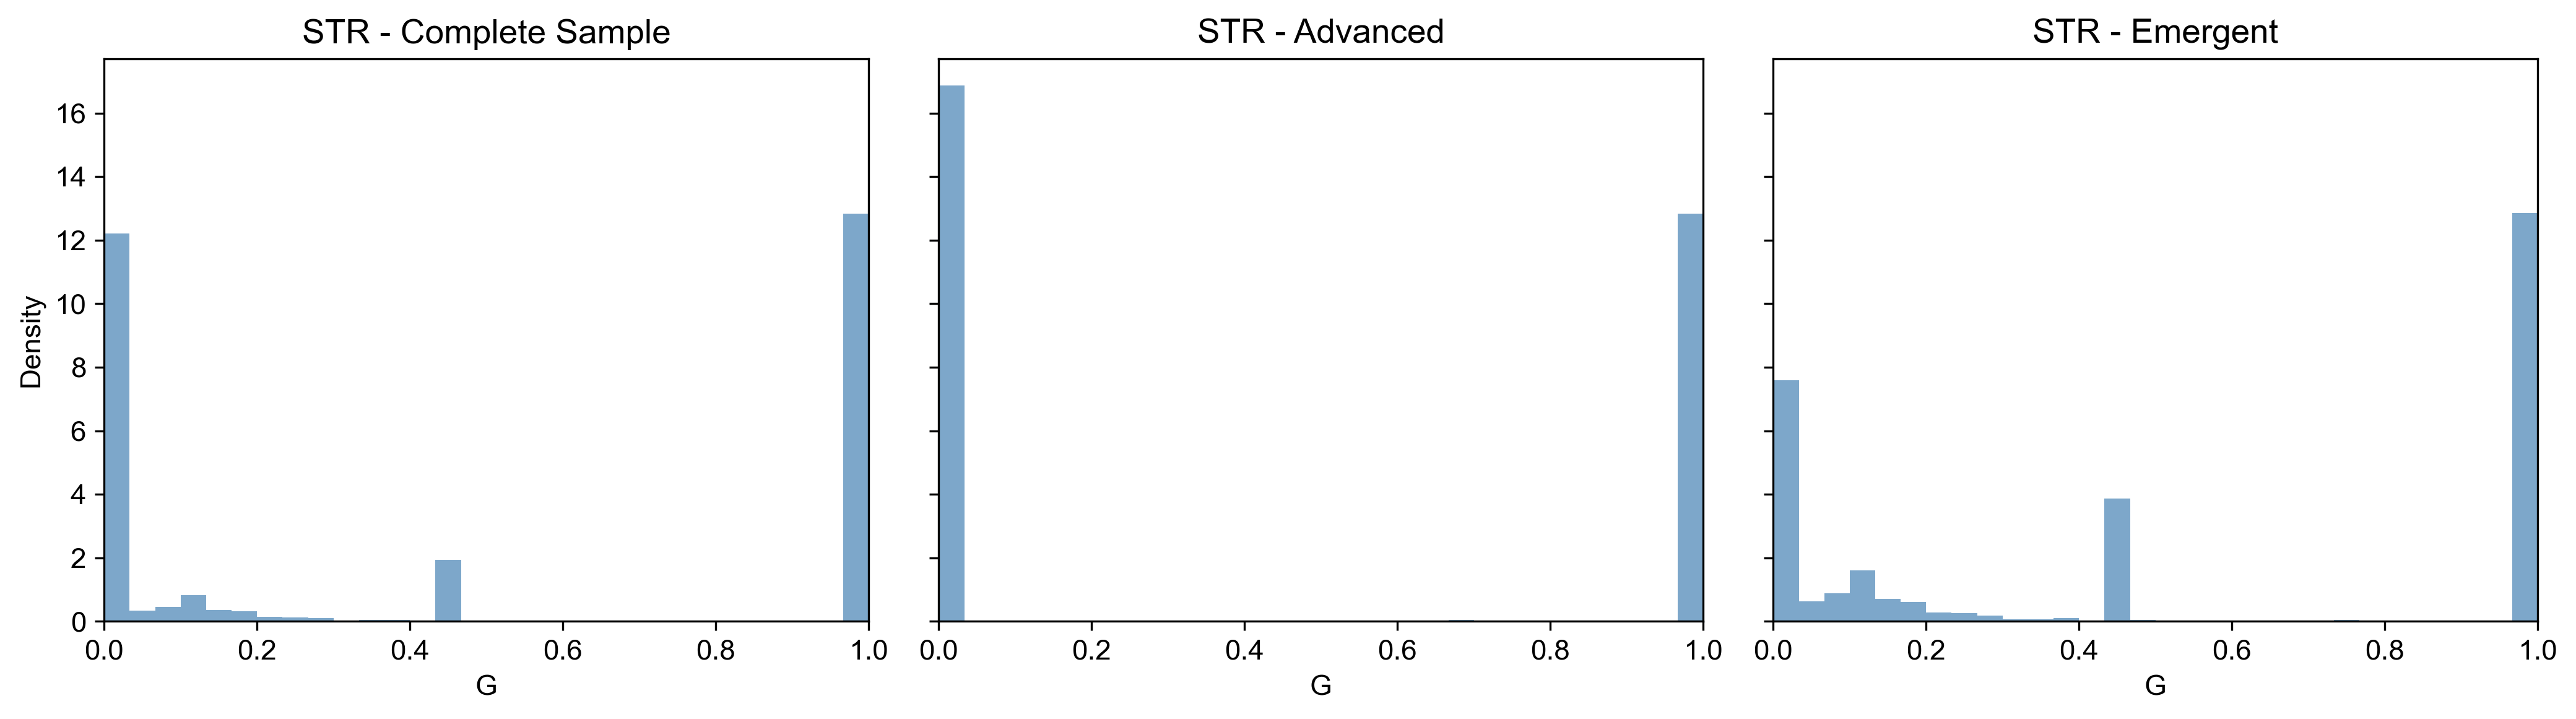

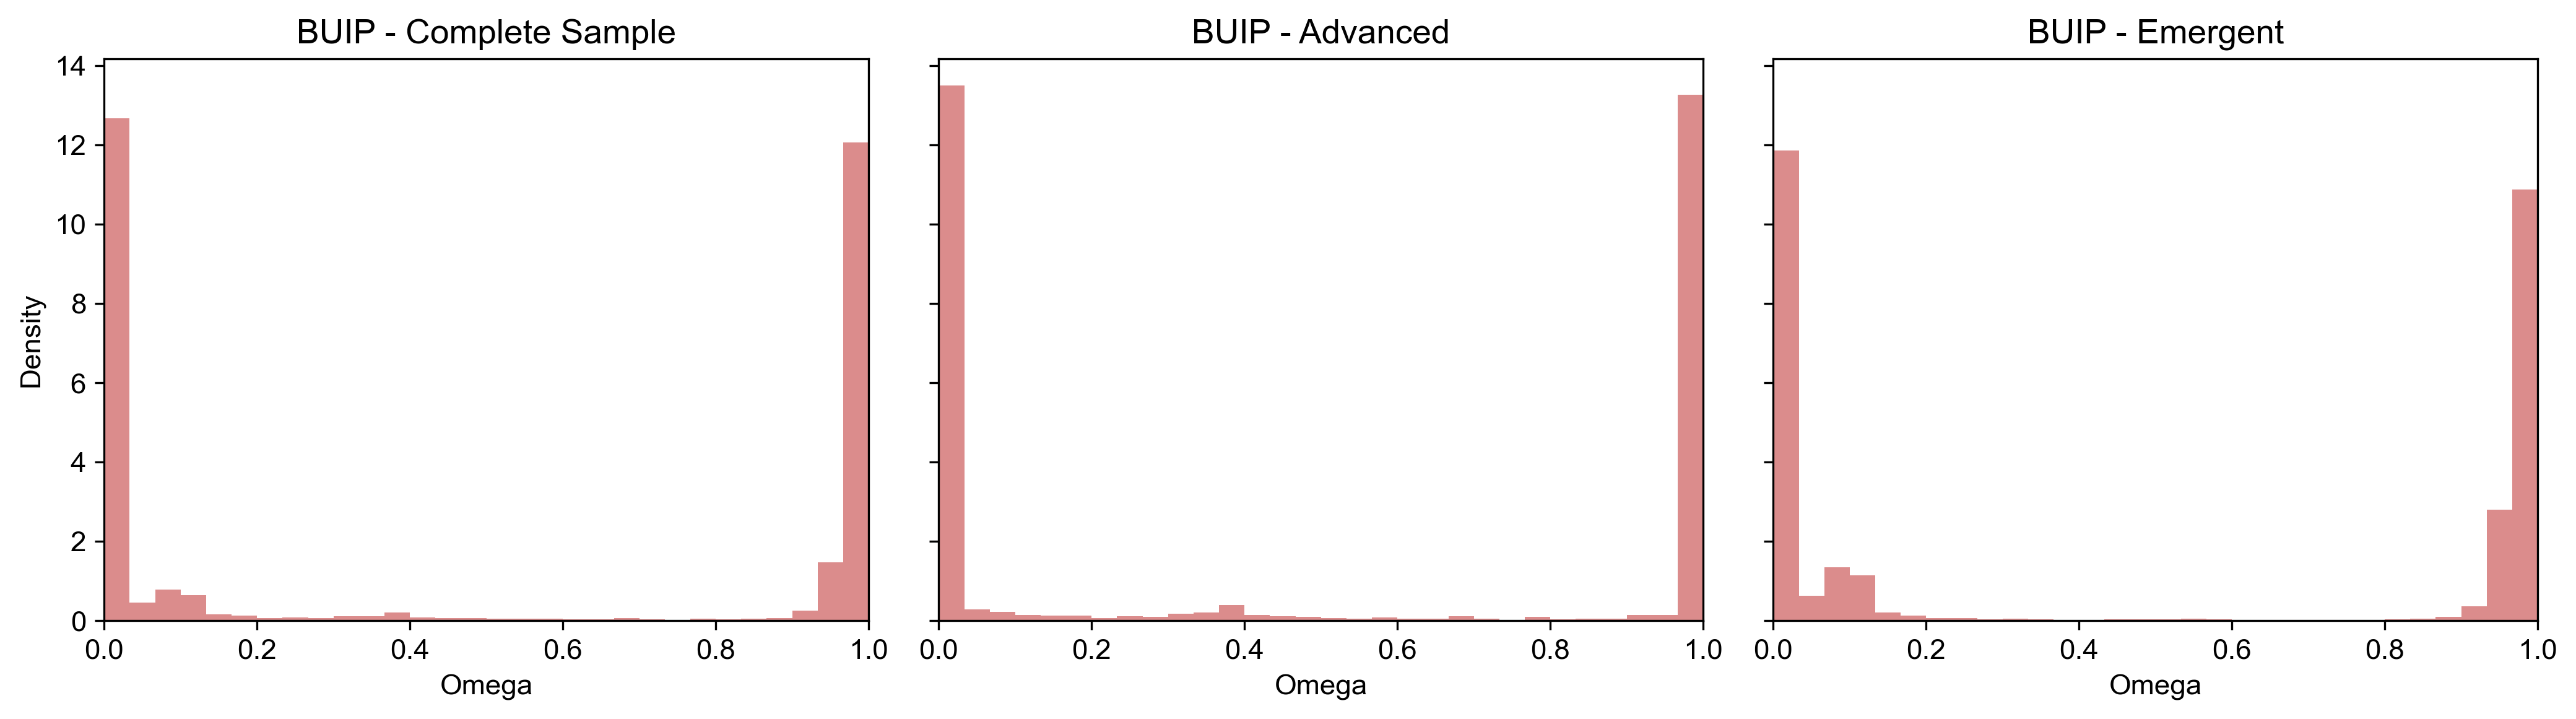

In [15]:
# Define Advanced and Emergent groups (adjust as needed)
ADVANCED = {
    'Australia','Canada','Euro Area','Japan','New Zealand','Switzerland','United Kingdom'
}
EMERGENT = set(COUNTRIES.keys()) - ADVANCED

# Helper to compute regime distribution and prevalence
import matplotlib.pyplot as plt
import numpy as np

def regime_stats_for_group(results_dict, group_names, model_label):
    """
    Compute regime statistics for a group of countries.
    
    Handles both data structures:
    - STR results: {country: {'result': StrResult, 'z_name': str}}
    - BUIP results: {country: BuipResult}
    """
    G_vals = []
    chartist_pct = []
    fund_pct = []
    for c in group_names:
        if c in results_dict:
            entry = results_dict[c]
            # Handle STR structure: {'result': StrResult, 'z_name': ...}
            if isinstance(entry, dict) and 'result' in entry:
                res = entry['result']
            else:
                res = entry
            # Get G (STR) or omega (BUIP)
            if hasattr(res, 'G'):
                G = res.G
            elif hasattr(res, 'omega'):
                G = res.omega
            else:
                continue
            G_vals.append(G.dropna())
            chartist_pct.append(float((G < 0.2).mean()))
            fund_pct.append(float((G > 0.8).mean()))
    G_all = pd.concat(G_vals) if len(G_vals) else pd.Series([], dtype=float)
    return {
        'G_all': G_all,
        'chartist_mean': float(np.mean(chartist_pct)) if chartist_pct else np.nan,
        'fund_mean': float(np.mean(fund_pct)) if fund_pct else np.nan,
        'label': model_label
    }

# Plot regime distributions (1x3) for STR
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, (title, names) in enumerate([
    ("Complete Sample", COUNTRIES.keys()),
    ("Advanced", ADVANCED),
    ("Emergent", EMERGENT)
]):
    stats = regime_stats_for_group(str_results, names, 'STR')
    axes[i].hist(stats['G_all'], bins=30, density=True, color='steelblue', alpha=0.7)
    axes[i].set_title(f"STR - {title}")
    axes[i].set_xlabel("G")
    axes[i].set_xlim(0,1)
axes[0].set_ylabel("Density")
plt.tight_layout()

# Save STR histogram grid
path_png = agg_fig_dir / 'str_regime_distribution_groups.png'
path_pdf = agg_fig_dir / 'str_regime_distribution_groups.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")

# Repeat for BUIP
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, (title, names) in enumerate([
    ("Complete Sample", COUNTRIES.keys()),
    ("Advanced", ADVANCED),
    ("Emergent", EMERGENT)
]):
    stats = regime_stats_for_group(buip_results, names, 'BUIP')
    axes[i].hist(stats['G_all'], bins=30, density=True, color='indianred', alpha=0.7)
    axes[i].set_title(f"BUIP - {title}")
    axes[i].set_xlabel("Omega")
    axes[i].set_xlim(0,1)
axes[0].set_ylabel("Density")
plt.tight_layout()

# Save BUIP histogram grid
path_png = agg_fig_dir / 'buip_regime_distribution_groups.png'
path_pdf = agg_fig_dir / 'buip_regime_distribution_groups.pdf'
fig.savefig(path_png, dpi=300)
fig.savefig(path_pdf)
print(f"✓ Saved: {path_png.name}, {path_pdf.name}")


## 5.2 Individual Country Plots

### 5.2.1 Stack: FX Returns, Transition Var, Transition Function

In [16]:
"""
Generate detailed country-specific plots for STR and BUIP models.
Each plot shows the transition variable, transition function, and regime evolution.
"""
import importlib
import src.output_figures
importlib.reload(src.output_figures)
from src.output_figures import plot_country_detailed_analysis
from src.utils import build_beh_sample

print("\n" + "="*60)
print("GENERATING DETAILED COUNTRY PLOTS")
print("="*60)

# ============================================================================
# STR Detailed Plots
# ============================================================================
print("\nSTR plots:")
for country_name in str_results.keys():
    try:
        result_dict = str_results[country_name]
        str_result = result_dict['result']
        z_name = result_dict['z_name']
        
        # Get country data and transition variable
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        z_candidates = build_z_candidates(country_df)
        z_series = z_candidates[z_name]
        y = country_df['r_s'] - (country_df['i_for'] - country_df['i_dom'])
        
        # Generate and save plot
        save_path = country_fig_dir / f"{country_name.replace(' ', '_')}_str_detailed.pdf"
        plot_country_detailed_analysis(
            y=y,
            transition_var=z_series,
            transition_func=str_result.G,
            c_threshold=str_result.params['c'],
            country=country_name,
            var_name=z_name,
            model_type='STR',
            save_path=save_path
        )
        print(f"  ✓ {country_name}")
    except Exception as e:
        print(f"  ✗ {country_name}: {e}")

# ============================================================================
# BUIP Detailed Plots
# ============================================================================
print("\nBUIP plots:")
for country_name in buip_results.keys():
    try:
        buip_result = buip_results[country_name]
        
        # Get country data
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        buip_df = build_beh_sample(country_df)
        y = buip_df['y']
        utility_diff = buip_result.U_f - buip_result.U_c
        
        # Generate and save plot
        save_path = country_fig_dir / f"{country_name.replace(' ', '_')}_buip_detailed.pdf"
        plot_country_detailed_analysis(
            y=y,
            transition_var=utility_diff,
            transition_func=buip_result.omega,
            c_threshold=buip_result.params['c'],
            country=country_name,
            var_name='Utility Differential',
            model_type='BUIP',
            save_path=save_path
        )
        print(f"  ✓ {country_name}")
    except Exception as e:
        print(f"  ✗ {country_name}: {e}")

print("\n✓ Detailed country plots completed")


GENERATING DETAILED COUNTRY PLOTS

STR plots:
  ✓ Australia
  ✓ Brazil
  ✓ Canada
  ✓ Euro Area
  ✓ Indonesia
  ✓ Japan
  ✓ Korea
  ✓ Mexico
  ✓ New Zealand
  ✓ Philippines
  ✓ Switzerland
  ✓ Thailand
  ✓ Türkiye
  ✓ United Kingdom

BUIP plots:
  ✓ Australia
  ✓ Brazil
  ✓ Canada
  ✓ Euro Area
  ✓ Indonesia
  ✓ Japan
  ✓ Korea
  ✓ Mexico
  ✓ New Zealand
  ✓ Philippines
  ✓ Switzerland
  ✓ Thailand
  ✓ Türkiye
  ✓ United Kingdom

✓ Detailed country plots completed


### 5.2.2 STR Scatter Plots

Individual country scatter plots showing:
- **STR**: Transition function G(z) vs transition variable z with fitted logistic curve
- **BUIP**: Market share ω vs utility differential with fitted logistic curve

In [17]:
"""
Generate STR scatter plots: Transition function G(z) vs transition variable z
Each country gets an individual scatter plot with fitted logistic curve overlay.
"""
from scipy.special import expit

print("\n" + "="*60)
print("GENERATING STR SCATTER PLOTS (G vs z)")
print("="*60)

for country_name in str_results.keys():
    try:
        result_dict = str_results[country_name]
        str_result = result_dict['result']
        z_name = result_dict['z_name']
        
        # Get country data and transition variable
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        z_candidates = build_z_candidates(country_df)
        z_series = z_candidates[z_name]
        
        # Get transition function values
        G_series = str_result.G
        
        # Align and get non-missing observations
        mask = z_series.notna() & G_series.notna()
        z_scatter = z_series[mask]
        G_scatter = G_series[mask]
        
        if len(z_scatter) == 0:
            print(f"  ✗ {country_name}: No valid observations")
            continue
        
        # Get parameters for fitted curve
        gamma_hat = float(str_result.params['gamma'])
        c = float(str_result.params['c'])
        
        # Compute standard deviation for normalization (matching your previous code)
        sd_z = float(z_scatter.std(ddof=1)) if np.isfinite(z_scatter.std(ddof=1)) and z_scatter.std(ddof=1) > 1e-12 else 1.0
        
        # Create grid for smooth logistic curve
        x_grid = np.linspace(float(z_scatter.min()), float(z_scatter.max()), 400)
        G_line = expit(gamma_hat * ((x_grid - c) / sd_z))
        
        # Create figure
        fig, ax = plt.subplots(figsize=(3.5, 2.5))
        
        # Scatter plot
        ax.scatter(z_scatter, G_scatter, s=2, color='k')
        
        # Fitted logistic curve
        ax.plot(x_grid, G_line, lw=0.5, color='k', alpha=0.3)
        
        # Formatting
        ax.set_xlim(x_grid.min(), x_grid.max())
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"{country_name}", fontsize=11)
        ax.set_xlabel(f"Transition Variable: {z_name}", fontsize=10)
        ax.set_ylabel("G(z)", fontsize=10)
        ax.tick_params(axis='both', labelsize=10)
        
        ax.margins(x=0, y=0)
        for spine in ["top", "right", "bottom", "left"]:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color("black")
        
        plt.tight_layout()
        
        # Save figure
        fig_path = country_fig_dir / f"{country_name.replace(' ', '_')}_str_scatter.pdf"
        fig.savefig(fig_path, bbox_inches='tight', dpi=600)
        plt.close(fig)
        
        print(f"  ✓ {country_name}")
        
    except Exception as e:
        print(f"  ✗ {country_name}: {e}")

print("\n✓ STR scatter plots completed")


GENERATING STR SCATTER PLOTS (G vs z)
  ✓ Australia
  ✓ Brazil
  ✓ Canada
  ✓ Euro Area
  ✓ Indonesia
  ✓ Japan
  ✓ Korea
  ✓ Mexico
  ✓ New Zealand
  ✓ Philippines
  ✓ Switzerland
  ✓ Thailand
  ✓ Türkiye
  ✓ United Kingdom

✓ STR scatter plots completed


### 5.2.3 Fitted vs Actual Exchange Rate Returns

In [18]:

"""
Generate fitted vs actual and residual plots for each country.
Two subplots per figure:
1. Top: Fitted values vs actual values
2. Bottom: Residuals over time
"""
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("\n" + "="*60)
print("GENERATING FITTED VS ACTUAL & RESIDUAL PLOTS")
print("="*60)

# ============================================================================
# STR Model Plots
# ============================================================================
print("\nSTR fitted vs actual plots:")
for country_name in str_results.keys():
    try:
        result_dict = str_results[country_name]
        str_result = result_dict['result']
        
        # Get fitted values, actual values, and residuals
        y_actual = str_result.y_fit.index.to_series().map(
            lambda date: str_result.y_fit.loc[date] + str_result.resid.loc[date]
        )
        y_fit = str_result.y_fit
        resid = str_result.resid
        dates = str_result.y_fit.index
        
        # Create figure with 2 subplots (stacked)
        fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
        
        # Top panel: Fitted vs Actual
        axes[0].plot(dates, y_actual, color='black', linewidth=0.8, label='Actual', alpha=0.7)
        axes[0].plot(dates, y_fit, color='red', linewidth=0.8, label='Fitted', linestyle='--')
        axes[0].set_ylabel('Exchange Rate Returns')
        axes[0].set_title(f'{country_name} - STR Model')
        axes[0].legend(loc='best', frameon=False, fontsize=9)
        axes[0].grid(False)
        axes[0].axhline(0, color='gray', linewidth=0.5, linestyle=':')
        
        # Bottom panel: Residuals
        axes[1].plot(dates, resid, color='black', linewidth=0.6)
        axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')
        axes[1].set_ylabel('Residuals')
        axes[1].set_xlabel('Date')
        axes[1].grid(False)
        
        # Format x-axis
        axes[1].xaxis.set_major_locator(mdates.YearLocator(base=5))
        axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
        
        plt.tight_layout()
        
        # Save figure
        fig_path_pdf = country_fig_dir / f"{country_name.replace(' ', '_')}_str_fitted_residuals.pdf"
        fig_path_png = country_fig_dir / f"{country_name.replace(' ', '_')}_str_fitted_residuals.png"
        fig.savefig(fig_path_pdf, bbox_inches='tight', dpi=300)
        fig.savefig(fig_path_png, bbox_inches='tight', dpi=300)
        plt.close(fig)
        
        print(f"  ✓ {country_name}")
        
    except Exception as e:
        print(f"  ✗ {country_name}: {e}")

# ============================================================================
# BUIP Model Plots
# ============================================================================
print("\nBUIP fitted vs actual plots:")
for country_name in buip_results.keys():
    try:
        buip_result = buip_results[country_name]
        
        # Get fitted values, actual values, and residuals
        y_actual = buip_result.y_fit.index.to_series().map(
            lambda date: buip_result.y_fit.loc[date] + buip_result.resid.loc[date]
        )
        y_fit = buip_result.y_fit
        resid = buip_result.resid
        dates = buip_result.y_fit.index
        
        # Create figure with 2 subplots (stacked)
        fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
        
        # Top panel: Fitted vs Actual
        axes[0].plot(dates, y_actual, color='black', linewidth=0.8, label='Actual', alpha=0.7)
        axes[0].plot(dates, y_fit, color='red', linewidth=0.8, label='Fitted', linestyle='--')
        axes[0].set_ylabel('Exchange Rate Returns')
        axes[0].set_title(f'{country_name} - BUIP Model')
        axes[0].legend(loc='best', frameon=False, fontsize=9)
        axes[0].grid(False)
        axes[0].axhline(0, color='gray', linewidth=0.5, linestyle=':')
        
        # Bottom panel: Residuals
        axes[1].plot(dates, resid, color='black', linewidth=0.6)
        axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')
        axes[1].set_ylabel('Residuals')
        axes[1].set_xlabel('Date')
        axes[1].grid(False)
        
        # Format x-axis
        axes[1].xaxis.set_major_locator(mdates.YearLocator(base=5))
        axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
        
        plt.tight_layout()
        
        # Save figure
        fig_path_pdf = country_fig_dir / f"{country_name.replace(' ', '_')}_buip_fitted_residuals.pdf"
        fig_path_png = country_fig_dir / f"{country_name.replace(' ', '_')}_buip_fitted_residuals.png"
        fig.savefig(fig_path_pdf, bbox_inches='tight', dpi=300)
        fig.savefig(fig_path_png, bbox_inches='tight', dpi=300)
        plt.close(fig)
        
        print(f"  ✓ {country_name}")
        
    except Exception as e:
        print(f"  ✗ {country_name}: {e}")

print("\n✓ Fitted vs actual and residual plots completed")



GENERATING FITTED VS ACTUAL & RESIDUAL PLOTS

STR fitted vs actual plots:
  ✓ Australia
  ✓ Brazil
  ✓ Canada
  ✓ Euro Area
  ✓ Indonesia
  ✓ Japan
  ✓ Korea
  ✓ Mexico
  ✓ New Zealand
  ✓ Philippines
  ✓ Switzerland
  ✓ Thailand
  ✓ Türkiye
  ✓ United Kingdom

BUIP fitted vs actual plots:
  ✓ Australia
  ✓ Brazil
  ✓ Canada
  ✓ Euro Area
  ✓ Indonesia
  ✓ Japan
  ✓ Korea
  ✓ Mexico
  ✓ New Zealand
  ✓ Philippines
  ✓ Switzerland
  ✓ Thailand
  ✓ Türkiye
  ✓ United Kingdom

✓ Fitted vs actual and residual plots completed


### 5.2.4 BUIP Scatter Plots

In [19]:
"""
Generate BUIP scatter plots: Market share ω vs utility differential
Each country gets an individual scatter plot with fitted logistic curve overlay.
"""
from scipy.special import expit

print("\n" + "="*60)
print("GENERATING BUIP SCATTER PLOTS (ω vs U_f - U_c)")
print("="*60)

for country_name in buip_results.keys():
    try:
        buip_result = buip_results[country_name]
        
        # Get country data
        country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
        buip_df = build_beh_sample(country_df)
        
        # Get utility differential and omega
        u_diff = buip_result.U_f - buip_result.U_c
        omega_series = buip_result.omega
        
        # Align on common index and get non-missing observations
        w_aln = omega_series.reindex(u_diff.index)
        mask = u_diff.notna() & w_aln.notna()
        u_scatter = u_diff[mask]
        w_scatter = w_aln[mask]
        
        if len(u_scatter) == 0:
            print(f"  ✗ {country_name}: No valid observations")
            continue
        
        # Get parameters for fitted curve
        gamma_hat = float(buip_result.params['gamma'])
        c = float(buip_result.params['c'])
        scale_d = float(buip_result.scale_d) 
        
        # Compute standard deviation for normalization (matching your previous code)
        sd_d = float(u_scatter.std(ddof=1)) if np.isfinite(u_scatter.std(ddof=1)) and u_scatter.std(ddof=1) > 1e-12 else 1.0
        
        # Create grid for smooth logistic curve
        x_grid = np.linspace(float(u_scatter.min()), float(u_scatter.max()), 400)
        w_line = expit((gamma_hat / scale_d) * (x_grid - c))
        
        # Create figure
        fig, ax = plt.subplots(figsize=(3.5, 2.5))
        
        # Scatter plot
        ax.scatter(u_scatter, w_scatter, s=2, color='k')
        
        # Fitted logistic curve
        ax.plot(x_grid, w_line, lw=0.5, color='k', alpha=0.3)
        
        # Formatting
        ax.set_xlim(x_grid.min(), x_grid.max())
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"{country_name}", fontsize=11)
        ax.set_xlabel("Utility Differential (U_f - U_c)", fontsize=10)
        ax.set_ylabel("ω", fontsize=10)
        ax.tick_params(axis='both', labelsize=10)
        
        ax.margins(x=0, y=0)
        for spine in ["top", "right", "bottom", "left"]:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color("black")
        
        plt.tight_layout()
        
        # Save figure
        fig_path = country_fig_dir / f"{country_name.replace(' ', '_')}_buip_scatter.pdf"
        fig.savefig(fig_path, bbox_inches='tight', dpi=600)
        plt.close(fig)
        
        print(f"  ✓ {country_name}")
        
    except Exception as e:
        print(f"  ✗ {country_name}: {e}")

print("\n✓ BUIP scatter plots completed")


GENERATING BUIP SCATTER PLOTS (ω vs U_f - U_c)
  ✓ Australia
  ✓ Brazil
  ✓ Canada
  ✓ Euro Area
  ✓ Indonesia
  ✓ Japan
  ✓ Korea
  ✓ Mexico
  ✓ New Zealand
  ✓ Philippines
  ✓ Switzerland
  ✓ Thailand
  ✓ Türkiye
  ✓ United Kingdom

✓ BUIP scatter plots completed


# 6 Model Comparison
Compare AIC and BIC across Linear ARX, STR, and BUIP models. Lower values indicate better fit.

In [20]:
"""
Comprehensive Model Comparison Table: RMSE and AIC
Combines all performance metrics in a single publication-ready table.
The lowest value for each metric within each country is highlighted in bold.
"""
from src.econometrics import run_linear_arx_benchmark

# Compute RMSEs for linear ARX benchmark
lin_rmse = {}
for country_name in COUNTRIES.keys():
    country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
    try:
        lin_res = run_linear_arx_benchmark(country_df)
        lin_rmse[country_name] = float(lin_res['fit'].iloc[0]['RMSE'])
    except Exception as e:
        lin_rmse[country_name] = np.nan
        print(f"Linear ARX failed for {country_name}: {e}")

# Collect AIC for all three models
lin_aic = {}
for country_name in COUNTRIES.keys():
    country_df = df_panel[df_panel['country'] == country_name].copy().set_index('date').sort_index()
    try:
        lin_res = run_linear_arx_benchmark(country_df)
        lin_aic[country_name] = float(lin_res['fit'].iloc[0]['AIC'])
    except Exception as e:
        lin_aic[country_name] = np.nan

# Build comprehensive comparison table with RMSE and AIC
comprehensive_data = []
for country in COUNTRIES.keys():
    row = {'Country': country}
    
    # Linear ARX
    row['Linear_RMSE'] = lin_rmse.get(country, np.nan)
    row['Linear_AIC'] = lin_aic.get(country, np.nan)
    
    # STR
    if country in str_results:
        row['STR_RMSE'] = str_results[country]['result'].rmse
        row['STR_AIC'] = str_results[country]['result'].aic
    else:
        row['STR_RMSE'] = np.nan
        row['STR_AIC'] = np.nan
    
    # BUIP
    if country in buip_results:
        row['BUIP_RMSE'] = buip_results[country].rmse
        row['BUIP_AIC'] = buip_results[country].aic
    else:
        row['BUIP_RMSE'] = np.nan
        row['BUIP_AIC'] = np.nan
    
    comprehensive_data.append(row)

df_comprehensive = pd.DataFrame(comprehensive_data)

print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON TABLE (RMSE, AIC)")
print("="*100)
print("\n" + df_comprehensive.round(2).to_string(index=False))

# Save CSV version (unformatted for reference)
csv_path = tables_dir / 'comprehensive_model_comparison.csv'
df_comprehensive.to_csv(csv_path, index=False)
print(f"\n✓ Saved CSV: {csv_path.name}")

# ============================================================================
# Create publication-ready LaTeX table with bold highlighting for best values
# ============================================================================

def highlight_best_value(value, group_values, decimals=2):
    """
    Format a value and highlight it bold if it's the minimum in its group.
    For RMSE and AIC: lower is better.
    """
    if np.isnan(value):
        return ''
    
    # Find minimum valid (non-NaN) value in group
    valid_vals = [v for v in group_values if not np.isnan(v)]
    if not valid_vals or np.isnan(value):
        return f"{value:.{decimals}f}"
    
    min_val = min(valid_vals)
    
    # Bold if this is the minimum (best)
    if abs(value - min_val) < 1e-6:  # Account for floating point precision
        return f"\\textbf{{{value:.{decimals}f}}}"
    else:
        return f"{value:.{decimals}f}"

# Create LaTeX table
latex_data = []
for idx, row in df_comprehensive.iterrows():
    country_name = row['Country']
    
    # Get RMSE and AIC values for this country (to find minimum)
    rmse_vals = [row['Linear_RMSE'], row['STR_RMSE'], row['BUIP_RMSE']]
    aic_vals = [row['Linear_AIC'], row['STR_AIC'], row['BUIP_AIC']]
    
    latex_row = {
        'Country': country_name,
        'Linear_RMSE': highlight_best_value(row['Linear_RMSE'], rmse_vals, decimals=4),
        'STR_RMSE': highlight_best_value(row['STR_RMSE'], rmse_vals, decimals=4),
        'BUIP_RMSE': highlight_best_value(row['BUIP_RMSE'], rmse_vals, decimals=4),
        'Linear_AIC': highlight_best_value(row['Linear_AIC'], aic_vals, decimals=2),
        'STR_AIC': highlight_best_value(row['STR_AIC'], aic_vals, decimals=2),
        'BUIP_AIC': highlight_best_value(row['BUIP_AIC'], aic_vals, decimals=2),
    }
    latex_data.append(latex_row)

df_latex = pd.DataFrame(latex_data)

# Create table with proper column grouping in LaTeX
latex_content = r"""
\begin{table}[htbp]
\centering
\caption{Comprehensive Model Comparison: RMSE and AIC by Country}
\label{tab:comprehensive_model_comparison}
\begin{tabular}{l|ccc|ccc}
\toprule
 & \multicolumn{3}{c|}{RMSE (lower is better)} & \multicolumn{3}{c}{AIC (lower is better)} \\
Country & Linear & STR & BUIP & Linear & STR & BUIP \\
\midrule
"""

for _, row in df_latex.iterrows():
    latex_content += f"{row['Country']:20s} & {row['Linear_RMSE']:>10s} & {row['STR_RMSE']:>10s} & {row['BUIP_RMSE']:>10s} & {row['Linear_AIC']:>10s} & {row['STR_AIC']:>10s} & {row['BUIP_AIC']:>10s} \\\\\n"

latex_content += r"""\bottomrule
\end{tabular}
\begin{tablenotes}[para]
\small
\textit{Note}: Bold values indicate the best (lowest) measure for each metric within each country. RMSE = Root Mean Squared Error, AIC = Akaike Information Criterion. Linear = Linear ARX model, STR = Smooth Transition Regression, BUIP = Behavioral Uncovered Interest Parity.
\end{tablenotes}
\end{table}
"""

# Save LaTeX file
tex_path = tables_dir / 'comprehensive_model_comparison.tex'
with open(tex_path, 'w') as f:
    f.write(latex_content)

print(f"✓ Saved LaTeX: {tex_path.name}")

print("\n" + "="*100)
print("Table saved in publication-ready format")
print("="*100)



COMPREHENSIVE MODEL COMPARISON TABLE (RMSE, AIC)

       Country  Linear_RMSE  Linear_AIC  STR_RMSE  STR_AIC  BUIP_RMSE  BUIP_AIC
     Australia         0.03    -3506.13      0.03 -3485.40       0.03  -3494.91
        Brazil         0.12    -2180.25      0.11 -2206.95       0.11  -2281.42
        Canada         0.02    -3981.07      0.02 -3971.79       0.02  -3975.31
     Euro Area         0.03    -2289.66      0.03 -2270.48       0.03  -2283.96
     Indonesia         0.06    -2608.09      0.06 -2644.93       0.04  -2888.09
         Japan         0.03    -3339.64      0.03 -3347.17       0.03  -3335.19
         Korea         0.03    -3618.03      0.03 -3646.03       0.03  -3657.41
        Mexico         0.05    -2999.03      0.04 -3189.84       0.05  -3004.90
   New Zealand         0.03    -3247.73      0.03 -3236.92       0.03  -3242.61
   Philippines         0.03    -3332.12      0.03 -3332.67       0.03  -3319.56
   Switzerland         0.03    -3574.48      0.03 -3573.40       0.03